# Loading data

In [1]:
#Import libraries and load data
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from category_encoders.target_encoder import TargetEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [2]:
transactions = pd.read_csv('trans_merged.csv')
transactions.head()

,date,user_id,amount,use_chip,merchant_id,is_fraud,card_brand,abs_amount,is_zscore_outlier,user_txn_count_24h,...,mean_gap_last5,std_gap_last5,first_time_and_high_amount,first_time_and_far,first_time_and_night,prev_city,city_changed,city_change_fast,night_city_change,night_x_velocity
0,2022-01-01 00:46:02,0,179.28,swipe transaction,55060,0,Visa,179.28,0,0.0,...,24309.8,16272.528175,0,1,1,bloemfontein,1,0,0,0.0
1,2022-01-01 05:02:57,0,5724.00,chip transaction,3558,0,Visa,5724.00,1,1.0,...,63794.8,119358.972303,0,1,1,bloemfontein,0,0,0,0.0
2,2022-01-01 06:04:41,0,987.12,chip transaction,32164,0,Visa,987.12,0,2.0,...,14247.4,9510.517457,0,1,0,bloemfontein,0,0,0,0.0
3,2022-01-01 07:49:43,0,279.18,swipe transaction,60510,0,Visa,279.18,0,3.0,...,4593.6,4229.278993,0,1,0,bloemfontein,0,0,0,0.0
4,2022-01-01 14:07:18,0,138.60,chip transaction,98648,0,Visa,138.60,0,4.0,...,15950.4,13099.594929,0,1,0,bloemfontein,0,0,0,0.0


In [3]:
transactions.dtypes

date                            object
user_id                          int64
amount                         float64
use_chip                        object
merchant_id                      int64
is_fraud                         int64
card_brand                      object
abs_amount                     float64
is_zscore_outlier                int64
user_txn_count_24h             float64
user_txn_count_7d              float64
user_amt_sum_24h               float64
user_avg_amt_24h               float64
is_first_time_user_mcc           int64
is_first_time_user_merchant      int64
is_first_time_user_city          int64
user_hour_seen_before            int64
is_first_time_user_hour          int64
is_same_city                     int64
is_same_region                   int64
is_different_region              int64
z_amount_user                  float64
amount_user_median_ratio       float64
user_hour_mean                 float64
hour_deviation_user            float64
user_hist_fraud_rate     

In [4]:
# Inspect unique values first
print(transactions['use_chip'].value_counts(dropna=False))

# Create a clean mapping
use_chip_map = {
    'online transaction': 0,
    'swipe transaction': 1,
    'chip transaction': 2,
    # add any others you see above
}

transactions['use_chip'] = (
    transactions['use_chip']
    .map(use_chip_map)
    .fillna(-1)  # unknown / missing
).astype('int8')

use_chip
swipe transaction     4617262
chip transaction      2990316
online transaction    1007955
Name: count, dtype: int64


In [5]:
cols_to_drop2 = ['use_chip_encoded']

cols_to_drop2 = [c for c in cols_to_drop2 if c in transactions.columns]

print(f"Dropping {len(cols_to_drop2)} columns:", cols_to_drop2)

# Drop in-place (or assign back if you prefer)
transactions = transactions.drop(columns=cols_to_drop2)

Dropping 0 columns: []


In [6]:
from sklearn.preprocessing import LabelEncoder

transactions['card_brand'] = transactions['card_brand'].fillna('Unknown')

le_brand = LabelEncoder()
transactions['card_brand_encoded'] = le_brand.fit_transform(
    transactions['card_brand']
)

transactions = transactions.drop(columns=['card_brand'])

In [7]:
cols_to_drop2 = ['merchant_id']

cols_to_drop2 = [c for c in cols_to_drop2 if c in transactions.columns]

print(f"Dropping {len(cols_to_drop2)} columns:", cols_to_drop2)

# Drop in-place (or assign back if you prefer)
transactions = transactions.drop(columns=cols_to_drop2)

Dropping 1 columns: ['merchant_id']


In [8]:
transactions.dtypes

date                            object
user_id                          int64
amount                         float64
use_chip                          int8
is_fraud                         int64
abs_amount                     float64
is_zscore_outlier                int64
user_txn_count_24h             float64
user_txn_count_7d              float64
user_amt_sum_24h               float64
user_avg_amt_24h               float64
is_first_time_user_mcc           int64
is_first_time_user_merchant      int64
is_first_time_user_city          int64
user_hour_seen_before            int64
is_first_time_user_hour          int64
is_same_city                     int64
is_same_region                   int64
is_different_region              int64
z_amount_user                  float64
amount_user_median_ratio       float64
user_hour_mean                 float64
hour_deviation_user            float64
user_hist_fraud_rate           float64
days_since_last_fraud          float64
hour_sin                 

In [9]:
transactions = transactions.drop(columns=['prev_city'])

In [10]:
transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")

In [11]:
transactions.dtypes

date                           datetime64[ns]
user_id                                 int64
amount                                float64
use_chip                                 int8
is_fraud                                int64
abs_amount                            float64
is_zscore_outlier                       int64
user_txn_count_24h                    float64
user_txn_count_7d                     float64
user_amt_sum_24h                      float64
user_avg_amt_24h                      float64
is_first_time_user_mcc                  int64
is_first_time_user_merchant             int64
is_first_time_user_city                 int64
user_hour_seen_before                   int64
is_first_time_user_hour                 int64
is_same_city                            int64
is_same_region                          int64
is_different_region                     int64
z_amount_user                         float64
amount_user_median_ratio              float64
user_hour_mean                    

In [12]:
transactions.columns

Index(['date', 'user_id', 'amount', 'use_chip', 'is_fraud', 'abs_amount',
       'is_zscore_outlier', 'user_txn_count_24h', 'user_txn_count_7d',
       'user_amt_sum_24h', 'user_avg_amt_24h', 'is_first_time_user_mcc',
       'is_first_time_user_merchant', 'is_first_time_user_city',
       'user_hour_seen_before', 'is_first_time_user_hour', 'is_same_city',
       'is_same_region', 'is_different_region', 'z_amount_user',
       'amount_user_median_ratio', 'user_hour_mean', 'hour_deviation_user',
       'user_hist_fraud_rate', 'days_since_last_fraud', 'hour_sin', 'hour_cos',
       'is_first_tx_user', 'is_unusual_brand_for_user', 'prev_amount',
       'amount_delta_last_txn', 'amount_pct_change', 'mean_last3_amount',
       'amount_vs_last3_mean', 'time_diff_sec', 'txn_rate_1h_vs_24h',
       'txn_rate_24h_vs_7d', 'gap', 'mean_gap_last5', 'std_gap_last5',
       'first_time_and_high_amount', 'first_time_and_far',
       'first_time_and_night', 'city_changed', 'city_change_fast',
       'n

# Data Split

In [ ]:
'''transactions['date'] = pd.to_datetime(transactions['date'])
transactions = transactions.sort_values('date')

transactions['month_block'] = transactions['date'].dt.to_period('M')

unique_months = transactions['month_block'].unique()
cutoff = int(len(unique_months) * 0.8)

train_months = unique_months[:cutoff]
test_months  = unique_months[cutoff:]

train_df = transactions[transactions['month_block'].isin(train_months)]
test_df  = transactions[transactions['month_block'].isin(test_months)]'''

In [ ]:
''''# target column
target_col = "is_fraud"

# TRAIN
y_train = train_df[target_col].copy()
X_train = train_df.drop(columns=[target_col])

# TEST
y_test = test_df[target_col].copy()
X_test = test_df.drop(columns=[target_col])
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)'''

X_train shape: (6702117, 48)
y_train shape: (6702117,)
X_test shape: (1913416, 48)
y_test shape: (1913416,)


In [ ]:
'''cols_to_remove = ['month_block', 'date']


X_test.drop(columns=cols_to_remove, inplace=True)
X_train.drop(columns=cols_to_remove, inplace=True)
X_train.head()'''

,user_id,amount,use_chip,abs_amount,is_zscore_outlier,user_txn_count_24h,user_txn_count_7d,user_amt_sum_24h,user_avg_amt_24h,is_first_time_user_mcc,...,mean_gap_last5,std_gap_last5,first_time_and_high_amount,first_time_and_far,first_time_and_night,city_changed,city_change_fast,night_city_change,night_x_velocity,card_brand_encoded
86083,24,47.16,2,47.16,0,1.0,13.0,1350.00,675.000,1,...,6346.8,2699.643532,0,1,1,1,0,0,0.0,3
5530667,1326,123.12,2,123.12,0,8.0,43.0,15344.64,1704.960,1,...,5220.6,7204.586928,0,1,1,1,0,0,0.0,3
2851362,696,25.56,1,25.56,0,4.0,47.0,4026.96,805.392,1,...,9067.8,9013.126744,0,1,1,1,0,0,0.0,3
6952054,1640,527.40,1,527.40,0,8.0,63.0,2371.86,263.540,1,...,21041.8,11816.030264,0,1,1,1,0,0,0.0,3
836621,185,55.44,2,55.44,0,3.0,27.0,4211.82,1052.955,1,...,36540.4,28459.692721,0,1,1,1,0,0,0.0,3


# Split with calibration

In [13]:
transactions = transactions.sort_values('date')

In [14]:
X = transactions.drop(columns=['is_fraud'])    # or whatever your target column is
y = transactions['is_fraud']

In [15]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    shuffle=False
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2222,   # because 0.2 / 0.9
    shuffle=False
)

In [18]:
cols_to_remove = ['date']


X_train.drop(columns=cols_to_remove, inplace=True)
X_calib.drop(columns=cols_to_remove, inplace=True)
X_train.head()

,user_id,amount,use_chip,abs_amount,is_zscore_outlier,user_txn_count_24h,user_txn_count_7d,user_amt_sum_24h,user_avg_amt_24h,is_first_time_user_mcc,...,mean_gap_last5,std_gap_last5,first_time_and_high_amount,first_time_and_far,first_time_and_night,city_changed,city_change_fast,night_city_change,night_x_velocity,card_brand_encoded
86083,24,47.16,2,47.16,0,1.0,13.0,1350.00,675.000,1,...,6346.8,2699.643532,0,1,1,1,0,0,0.0,3
5530667,1326,123.12,2,123.12,0,8.0,43.0,15344.64,1704.960,1,...,5220.6,7204.586928,0,1,1,1,0,0,0.0,3
2851362,696,25.56,1,25.56,0,4.0,47.0,4026.96,805.392,1,...,9067.8,9013.126744,0,1,1,1,0,0,0.0,3
6952054,1640,527.40,1,527.40,0,8.0,63.0,2371.86,263.540,1,...,21041.8,11816.030264,0,1,1,1,0,0,0.0,3
836621,185,55.44,2,55.44,0,3.0,27.0,4211.82,1052.955,1,...,36540.4,28459.692721,0,1,1,1,0,0,0.0,3


In [19]:
X_train = X_train.astype("float32")
X_calib = X_calib.astype("float32")
y_train = np.asarray(y_train)
y_calib = np.asarray(y_calib)

In [20]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy=0.02, random_state=42)  # raise fraud to ~2%
X_train_os, y_train_os = ros.fit_resample(X_train, y_train)

In [28]:
pd.Series(y_train_os).value_counts()

0    6022072
1     120441
Name: count, dtype: int64

In [42]:
import xgboost as xgb

# compute scale_pos_weight from original y_train (before oversampling)
class_counts = pd.Series(y_train_os).value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]

xgb_model = xgb.XGBClassifier(
    n_estimators=600,          # not too high, we’ll use early stopping
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.9,
    gamma=0.0,
    reg_alpha=1.0,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    eval_metric="auc",
    n_jobs=-1,                # if still memory‑heavy, set to 4 or 2
    random_state=42,
    early_stopping_rounds=50,
)

In [43]:
# use part of calibration set as eval set for early stopping
X_eval = X_calib.astype("float32")
y_eval = y_calib

xgb_model.fit(
    X_train_os,
    y_train_os,
    eval_set=[(X_eval, y_eval)],
    verbose=True
)

[0]	validation_0-auc:0.93721
[1]	validation_0-auc:0.94572
[2]	validation_0-auc:0.94741
[3]	validation_0-auc:0.94804
[4]	validation_0-auc:0.94951
[5]	validation_0-auc:0.95000
[6]	validation_0-auc:0.95033
[7]	validation_0-auc:0.95056
[8]	validation_0-auc:0.95090
[9]	validation_0-auc:0.95093
[10]	validation_0-auc:0.95115
[11]	validation_0-auc:0.95123
[12]	validation_0-auc:0.95127
[13]	validation_0-auc:0.95131
[14]	validation_0-auc:0.95139
[15]	validation_0-auc:0.95167
[16]	validation_0-auc:0.95161
[17]	validation_0-auc:0.95281
[18]	validation_0-auc:0.95276
[19]	validation_0-auc:0.95281
[20]	validation_0-auc:0.95296
[21]	validation_0-auc:0.95301
[22]	validation_0-auc:0.95307
[23]	validation_0-auc:0.95306
[24]	validation_0-auc:0.95307
[25]	validation_0-auc:0.95316
[26]	validation_0-auc:0.95314
[27]	validation_0-auc:0.95341
[28]	validation_0-auc:0.95361
[29]	validation_0-auc:0.95355
[30]	validation_0-auc:0.95362
[31]	validation_0-auc:0.95359
[32]	validation_0-auc:0.95369
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'auc'


In [44]:
from sklearn.linear_model import LogisticRegression

p_calib_raw = xgb_model.predict_proba(X_calib.astype("float32"))[:, 1].reshape(-1, 1)

calibrator = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)
calibrator.fit(p_calib_raw, y_calib)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [45]:
import numpy as np

def xgb_predict_proba_calibrated(X):
    X = np.asarray(X, dtype="float32")
    p_raw = xgb_model.predict_proba(X)[:, 1].reshape(-1, 1)
    return calibrator.predict_proba(p_raw)[:, 1]

def xgb_predict_label(X, threshold=0.5):
    p = xgb_predict_proba_calibrated(X)
    return (p >= threshold).astype(int)

In [47]:
X_test.head()

,date,user_id,amount,use_chip,abs_amount,is_zscore_outlier,user_txn_count_24h,user_txn_count_7d,user_amt_sum_24h,user_avg_amt_24h,...,mean_gap_last5,std_gap_last5,first_time_and_high_amount,first_time_and_far,first_time_and_night,city_changed,city_change_fast,night_city_change,night_x_velocity,card_brand_encoded
2956287,2024-09-12 04:16:05,720,452.34,1,452.34,0,6.0,19.0,6436.44,919.491429,...,7797.4,7794.682373,0,0,0,0,0,0,0.0,3
3594237,2024-09-12 04:16:16,877,1255.68,2,1255.68,0,7.0,39.0,8268.48,1033.560000,...,3052.6,2404.002246,0,0,0,0,0,0,0.0,2
1980837,2024-09-12 04:16:20,474,95.94,2,95.94,0,8.0,92.0,7847.82,871.980000,...,12778.6,3356.354689,0,0,0,0,0,0,0.0,2
1127704,2024-09-12 04:16:25,257,998.46,1,998.46,0,9.0,48.0,9796.32,979.632000,...,2318.4,2069.884127,0,0,0,0,0,0,0.0,3
5044447,2024-09-12 04:16:40,1214,2428.74,1,2428.74,0,4.0,52.0,3674.34,734.868000,...,17466.2,16559.927542,0,0,0,0,0,0,0.0,2


In [48]:
cols_to_remove = ['date']

X_test.drop(columns=cols_to_remove, inplace=True)

In [49]:
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

X_test_arr = X_test.astype("float32").values if hasattr(X_test, "values") else X_test.astype("float32")
y_test_arr = np.asarray(y_test)

y_prob = xgb_predict_proba_calibrated(X_test_arr)
y_pred = xgb_predict_label(X_test_arr, threshold=0.5)

print("Test AUC:", roc_auc_score(y_test_arr, y_prob))
print(classification_report(y_test_arr, y_pred))

# Recall at FPR = 1%
fpr, tpr, thresholds = roc_curve(y_test_arr, y_prob)
target_fpr = 0.01
idx = np.argmax(fpr <= target_fpr)
print("Recall @1% FPR:", tpr[idx])
print("Threshold @1% FPR:", thresholds[idx])

Test AUC: 0.95705862294773
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    860296
           1       0.00      0.00      0.00      1258

    accuracy                           1.00    861554
   macro avg       0.50      0.50      0.50    861554
weighted avg       1.00      1.00      1.00    861554



c:\Users\Geeks2_PC10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Geeks2_PC10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Geeks2_PC10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Recall @1% FPR: 0.0
Threshold @1% FPR: inf


In [41]:
import xgboost
print(xgb.__version__)

3.1.1


In [19]:
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.model_selection import train_test_split

# 1) Temporal split for calibration (no shuffle)
X_stack, X_calib, y_stack, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.2,    # 20% latest data for calibration
    shuffle=False
)

# 2) Make sure features are float32 to reduce memory
X_stack = X_stack.astype("float32")
X_calib = X_calib.astype("float32")

# Training

In [23]:
from imblearn.under_sampling import RandomUnderSampler

fraud_count = y_train.sum()          # 9951
target_total = 3_000_000
target_nonfraud = target_total - fraud_count

sampling_strategy = fraud_count / target_nonfraud

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Before undersample:\n", y_train.value_counts())
print("After undersample:\n", y_train_rus.value_counts())
print("Total rows after:", len(y_train_rus))

Before undersample:
 is_fraud
0    6692145
1       9972
Name: count, dtype: int64
After undersample:
 is_fraud
0    2990028
1       9972
Name: count, dtype: int64
Total rows after: 3000000


In [32]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit

lgbm = lgb.LGBMClassifier( 
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=255,
    max_depth=-1,
    min_data_in_leaf=30,
    subsample=0.8,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=42,
    max_bin=500,
    feature_fraction= 0.9,
    bagging_fraction= 0.8,
    bagging_freq= 5,

)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.9,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    use_label_encoder=False,
    eval_metric="auc",
    random_state=42,
    gamma=1,
    min_child_weight=2, 
    reg_alpha=1.0, 
    reg_lambda=2.0,
    tree_method="hist"
)

#rf = RandomForestClassifier(
#    n_estimators=150,
#    max_depth=10,
#    class_weight="balanced",
#    random_state=42
#)
base_models = [
    ('lgbm', lgbm),
    ('xgb_model', xgb_model),
#    ('rf', rf)
]

meta_learner = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=cv,
    n_jobs=-1,
    passthrough=False,
    stack_method="predict_proba"
)


In [ ]:
'''p_calib_raw = stacked_model.predict_proba(X_calib)[:, 1].reshape(-1, 1)

calibrator.fit(p_calib_raw, y_calib)

 y_test_proba = predict_proba_calibrated(X_test)'''

In [33]:
stacked_model.fit(X_stack, y_stack)

XGBoostError: [11:02:49] C:\actions-runner\_work\xgboost\xgboost\src\common\io.h:362: bad_malloc: Failed to allocate 197310330 bytes.

In [ ]:
'''# 3) Fit stacking model on the earlier period
stacked_model.fit(X_stack, y_stack)

# 4) Get predicted probabilities on calibration period
#    Use the positive class column [:, 1]
p_calib = stacked_model.predict_proba(X_calib)[:, 1].reshape(-1, 1)

# 5) Fit a 1D logistic regression for calibration (Platt scaling)
calibrator = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)
calibrator.fit(p_calib, y_calib)'''

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
'''def predict_proba_calibrated(X):
    X = X.astype("float32")
    p_raw = stacked_model.predict_proba(X)[:, 1].reshape(-1, 1)
    p_calibrated = calibrator.predict_proba(p_raw)[:, 1]
    return p_calibrated'''

In [ ]:
'''from sklearn.calibration import CalibratedClassifierCV

stacked_model.fit(X_train, y_train)'''

In [ ]:
'''y_pred_proba = predict_proba_calibrated(X_test)'''

In [22]:
y_pred_proba = stacked_model.predict_proba(X_test)[:, 1]

=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.97   1910572
           1       0.02      0.86      0.04      2844

    accuracy                           0.93   1913416
   macro avg       0.51      0.89      0.50   1913416
weighted avg       1.00      0.93      0.96   1913416

ROC-AUC: 0.9566
PR-AUC: 0.1792
Confusion Matrix:
 [[1781951  128621]
 [    406    2438]]


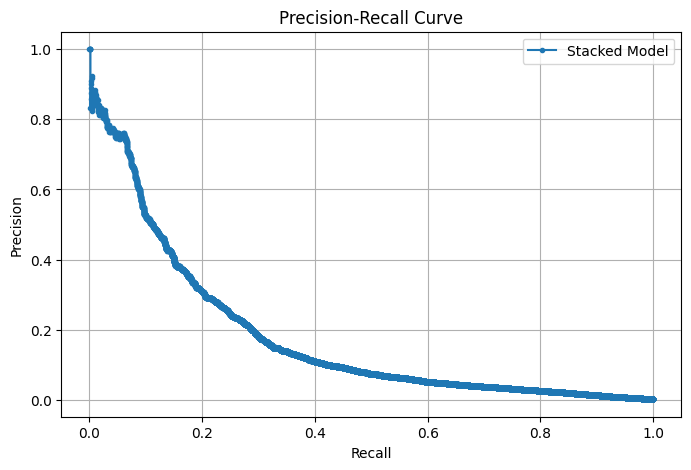

Optimal Threshold for max F1-score: 0.9776
Max F1-score at this threshold: 0.2506
=== Classification Report (optimal threshold) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1910572
           1       0.26      0.24      0.25      2844

    accuracy                           1.00   1913416
   macro avg       0.63      0.62      0.62   1913416
weighted avg       1.00      1.00      1.00   1913416

Confusion Matrix (Optimal Threshold):
 [[1908655    1917]
 [   2162     682]]


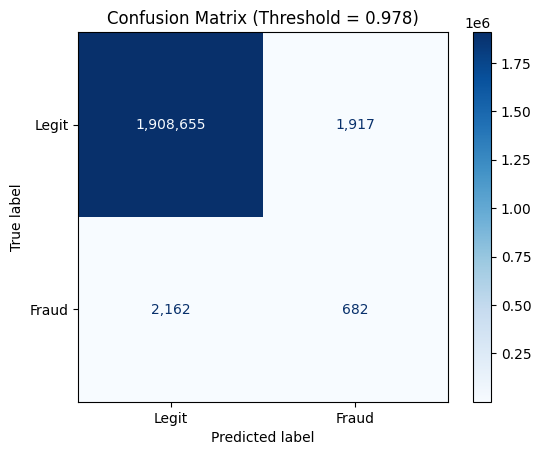

In [23]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np



# Step 2: Default predictions (threshold 0.5)
y_pred_default = (y_pred_proba >= 0.5).astype(int)


# Step 3: Metrics
print("=== Classification Report (threshold=0.5) ===")
print(classification_report(y_test, y_pred_default))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred_default)
print("Confusion Matrix:\n", cm)


# Step 4: Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
           
plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='.', label='Stacked Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


# Step 5: Find optimal threshold by maximizing F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # avoid division by zero
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold for max F1-score: {best_threshold:.4f}")
print(f"Max F1-score at this threshold: {best_f1:.4f}")

# Predictions at optimal threshold
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
print("=== Classification Report (optimal threshold) ===")
print(classification_report(y_test, y_pred_opt))

cm_opt = confusion_matrix(y_test, y_pred_opt)
print("Confusion Matrix (Optimal Threshold):\n", cm_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_opt,
    display_labels=['Legit', 'Fraud']
)

disp.plot(cmap='Blues', values_format=',')
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.show()

In [26]:
feature_names = X_stack.columns
lgbm_model = stacked_model.named_estimators_['lgbm']
xgb_model  = stacked_model.named_estimators_['xgb_model']

lgbm_importance = lgbm_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

lgbm_norm = lgbm_importance / (lgbm_importance.sum() + 1e-8)
xgb_norm  = xgb_importance  / (xgb_importance.sum()  + 1e-8)

combined_importance = (lgbm_norm + xgb_norm) / 2

In [27]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'LGBM_importance': lgbm_norm,
    'XGB_importance': xgb_norm,
    'combined_importance': combined_importance
})

importance_df = importance_df.sort_values(
    by='combined_importance',
    ascending=False
)

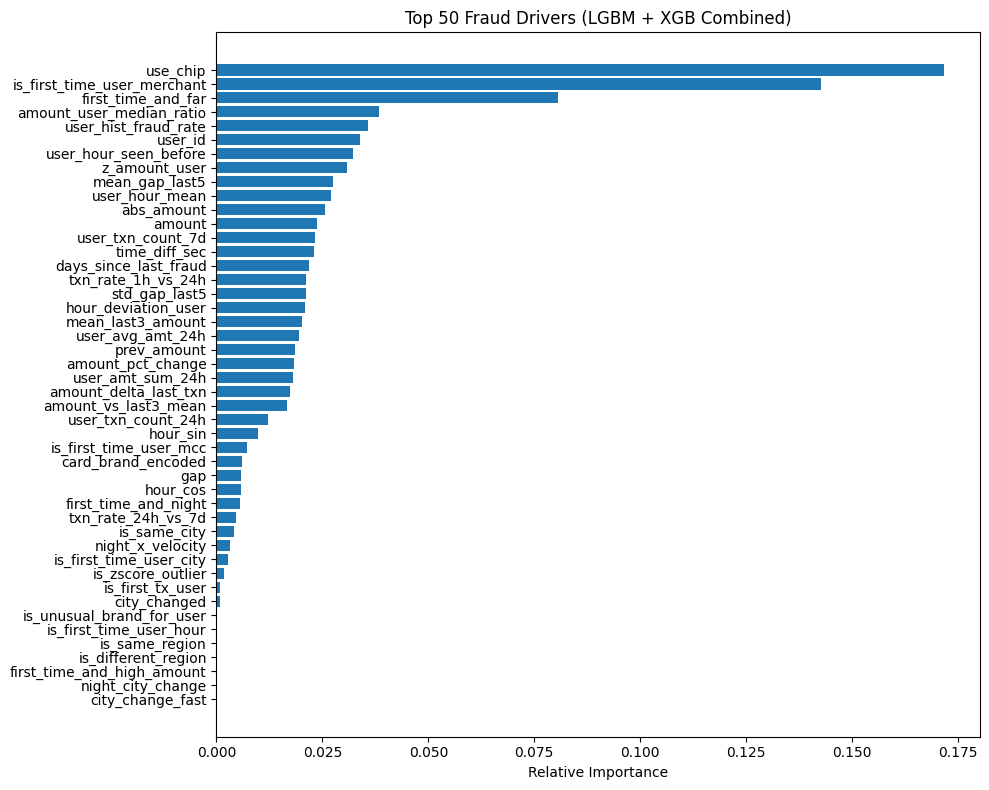

In [28]:
import matplotlib.pyplot as plt

top_50 = importance_df.head(50)

plt.figure(figsize=(10, 8))
plt.barh(
    top_50['feature'][::-1],
    top_50['combined_importance'][::-1]
)
plt.xlabel('Relative Importance')
plt.title('Top 50 Fraud Drivers (LGBM + XGB Combined)')
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Get recall at FPR 1%
target_fpr = 0.01
idx = np.argmax(fpr <= target_fpr)

print("Recall at FPR 1%:", tpr[idx])
print("Threshold at FPR 1%:", thresholds[idx])

Recall at FPR 1%: 0.0
Threshold at FPR 1%: inf


In [30]:
print("Top 60 Fraud Drivers:")
print(importance_df.head(60).to_string(index=False))

Top 60 Fraud Drivers:
                    feature  LGBM_importance  XGB_importance  combined_importance
                   use_chip         0.017196        0.326036             0.171616
is_first_time_user_merchant         0.012804        0.272628             0.142716
         first_time_and_far         0.002487        0.158602             0.080544
   amount_user_median_ratio         0.056825        0.019827             0.038326
       user_hist_fraud_rate         0.055503        0.015898             0.035700
                    user_id         0.062063        0.005592             0.033828
      user_hour_seen_before         0.058571        0.005907             0.032239
              z_amount_user         0.050635        0.011022             0.030829
             mean_gap_last5         0.048519        0.006706             0.027612
             user_hour_mean         0.049471        0.004386             0.026928
                 abs_amount         0.030847        0.020514             0.0